# 📈 Class 02: Data Visualization Introduction
### *From Code to Insight: Fundamentals of Matplotlib & Chart Selection*

**Topics Covered Today:**
1. **Fundamentals of Matplotlib** (Figure, Axes, OO Interface vs Pyplot)
2. **Distribution**: Histogram, KDE, Boxplot
3. **Comparison**: Bar chart (Vertical, Horizontal, Grouped)
4. **Relationship**: Scatter plot (with Hue & Size)
5. **Time Trend**: Line chart (Time-series analysis)
6. **Composition**: Stacked bar chart vs. Pie chart
7. **Correlation**: Scatter plot with regression & Heatmap
8. **Multiple Variables**: Pair plot (Multivariate analysis)
9. **Geographic Pattern**: Regional comparison / Choropleth representation

> 📌 **How to use this notebook:** All code is pre-written and ready to run! Focus on **how the visual tells a story**, the design choices, and the **Analytic Discussions** throughout.

## 0. Setup & Data Loading
Let's import `matplotlib.pyplot`, `seaborn`, `pandas`, and `numpy`. We will load two datasets:
1. `student_demographics_performance.csv` (250 students, cross-sectional demographics & exam performance)
2. `student_weekly_trends.csv` (12-week longitudinal study & quiz trends)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean, professional visual aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 110

# Load datasets
df = pd.read_csv('datasets/student_demographics_performance.csv')
df_weekly = pd.read_csv('datasets/student_weekly_trends.csv')

print(f"Students dataset: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Weekly trends dataset: {df_weekly.shape[0]} rows, {df_weekly.shape[1]} columns")
df.head(3)

Students dataset: 250 rows, 14 columns
Weekly trends dataset: 12 rows, 6 columns


,student_id,major,gender,state_region,study_hours_weekly,attendance_rate,midterm_score,final_score,grade,daily_sleep_hrs,daily_classes_hrs,daily_study_hrs,daily_leisure_hrs,daily_commute_hrs
0,STU_2001,Data Science,Female,Karnataka,22.9,65.0,94.3,77.0,B,7.1,5.3,3.3,6.5,1.8
1,STU_2002,Electrical Eng,Female,Maharashtra,26.9,78.3,81.9,84.5,B,6.9,5.9,3.8,5.9,1.5
2,STU_2003,Data Science,Female,Karnataka,24.2,75.5,79.8,79.3,B,7.8,5.1,3.5,6.1,1.5


---
## 1. Fundamentals of Matplotlib: Anatomy of a Figure

Matplotlib has two interfaces:
1. **`plt.plot()` (State-based / Pyplot)**: Quick and dirty, keeps track of current figure implicitly.
2. **`fig, ax = plt.subplots()` (Object-Oriented / OO Interface)**: **Industry standard**. You create a canvas (`Figure`) and one or more subplots (`Axes`). It gives you complete control over every element.

Let's visualize the anatomy of a plot using the OO interface:

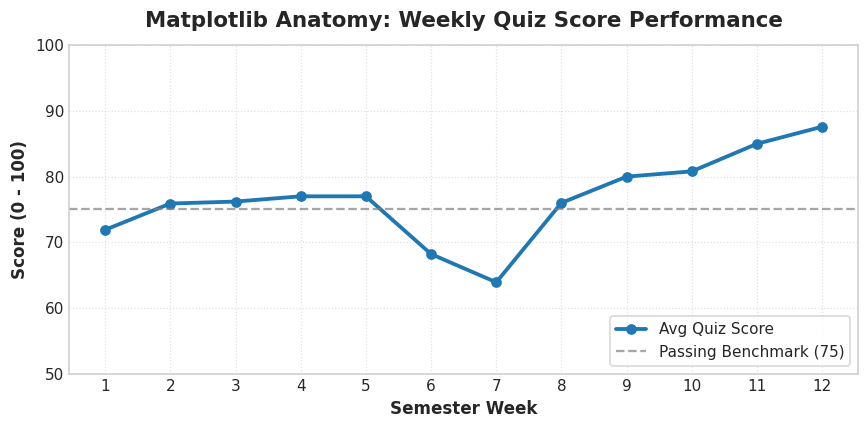

In [2]:
# 1. Create the Figure canvas and Axes
fig, ax = plt.subplots(figsize=(8, 4))

# 2. Plot data on the ax object
ax.plot(df_weekly['week'], df_weekly['avg_quiz_score'], marker='o', color='#1f77b4', linewidth=2.5, label='Avg Quiz Score')

# 3. Customize anatomy: Title, Labels, Limits, Ticks, Grid
ax.set_title('Matplotlib Anatomy: Weekly Quiz Score Performance', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Semester Week', fontsize=11, fontweight='semibold')
ax.set_ylabel('Score (0 - 100)', fontsize=11, fontweight='semibold')
ax.set_xticks(df_weekly['week'])  # Force every week to show on x-axis
ax.set_ylim(50, 100)
ax.axhline(75, color='gray', linestyle='--', alpha=0.7, label='Passing Benchmark (75)')
ax.legend(loc='lower right', frameon=True)
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

---
## 2. Distribution: Histogram, KDE, and Boxplot

**Purpose**: Understand the shape, spread, central peak, and anomalies in a single numerical variable.
- **Histogram**: Bins continuous data into buckets; shows frequency count.
- **KDE (Kernel Density Estimate)**: A smoothed continuous probability density curve.
- **Boxplot**: Compact 5-number summary; highlights outliers using Tukey's fences.

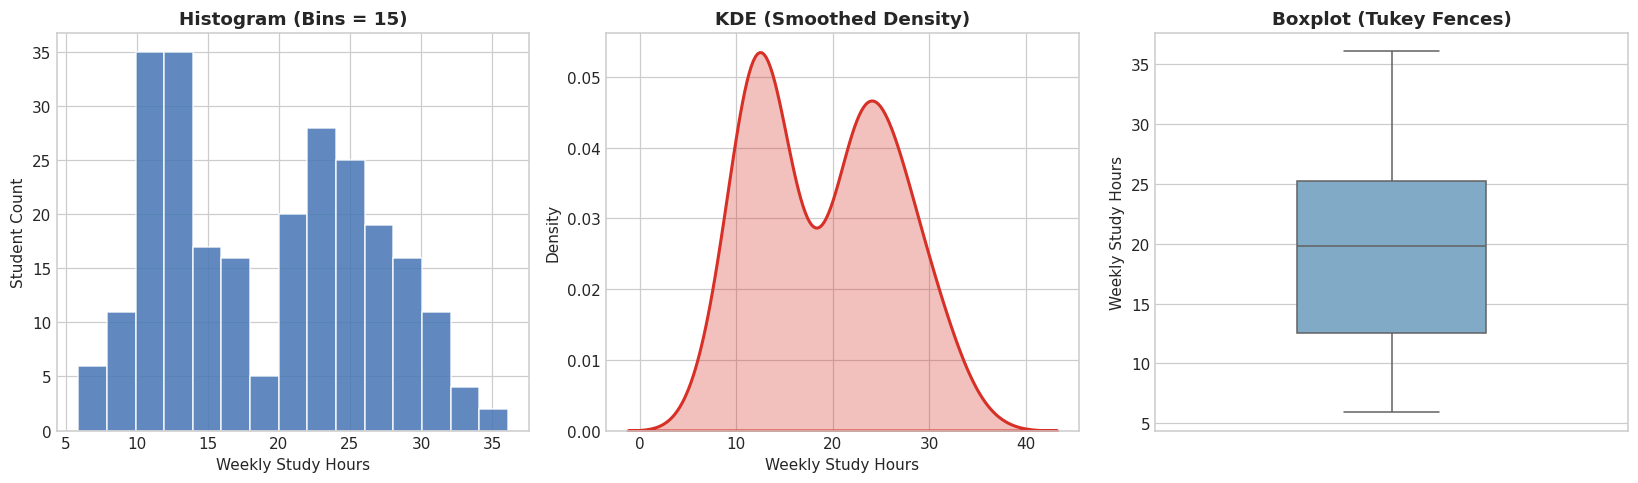

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# 1. Histogram
axes[0].hist(df['study_hours_weekly'], bins=15, color='#4575b4', edgecolor='white', alpha=0.85)
axes[0].set_title('Histogram (Bins = 15)', fontweight='bold')
axes[0].set_xlabel('Weekly Study Hours')
axes[0].set_ylabel('Student Count')

# 2. KDE Plot
sns.kdeplot(df['study_hours_weekly'], ax=axes[1], color='#d73027', fill=True, alpha=0.3, linewidth=2)
axes[1].set_title('KDE (Smoothed Density)', fontweight='bold')
axes[1].set_xlabel('Weekly Study Hours')
axes[1].set_ylabel('Density')

# 3. Boxplot
sns.boxplot(y=df['study_hours_weekly'], ax=axes[2], color='#74add1', width=0.4)
axes[2].set_title('Boxplot (Tukey Fences)', fontweight='bold')
axes[2].set_ylabel('Weekly Study Hours')

plt.tight_layout()
plt.show()

### 💬 Analytic Discussion 1: The Bimodal Mystery (Histogram vs. Boxplot)

**Look closely at the Histogram and KDE vs. the Boxplot above:**
1. In the **Histogram and KDE**, notice there are **TWO distinct peaks** (one around ~12 hours, another around ~25 hours). This is a **bimodal distribution** (two different cohorts of students).
2. Now look at the **Boxplot**: Does the boxplot reveal that there are two separate groups? Or does it just show a single box spanning across both?

**Key Analytic Insight:**  
*A boxplot summarizes the middle 50% between Q1 and Q3, but it completely conceals valleys, multimodality, or clusters! If you rely only on a boxplot, you would never know two distinct student types exist. Always pair boxplots with a histogram or KDE!*

---
## 3. Comparison: Bar Charts (Vertical, Horizontal, Grouped)

**Purpose**: Compare discrete categories or groups on a continuous metric.
- **Vertical Bar Chart**: Standard when categories have short names.
- **Horizontal Bar Chart (`barh`)**: Essential when category names are long to prevent overlapping labels.
- **Grouped Bar Chart**: Comparing multiple categories across a sub-dimension.

C:\Users\pavilion\AppData\Local\Temp\ipykernel_11072\2149374246.py:15: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='major', y='final_score', hue='gender', ci=None, ax=axes[1], palette='Set2')


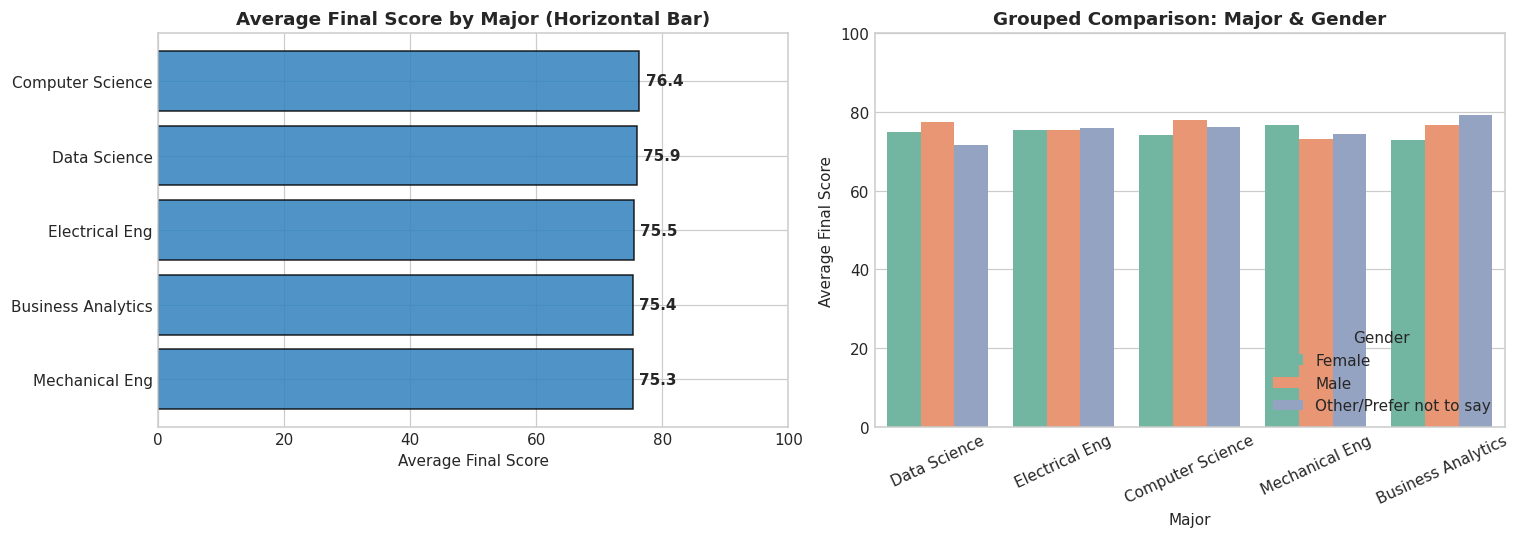

In [4]:
# Compute average score by major
major_stats = df.groupby('major')['final_score'].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Horizontal Bar Chart (Clean for reading major names)
axes[0].barh(major_stats.index, major_stats.values, color='#3182bd', edgecolor='black', alpha=0.85)
axes[0].set_title('Average Final Score by Major (Horizontal Bar)', fontweight='bold')
axes[0].set_xlabel('Average Final Score')
axes[0].set_xlim(0, 100)  # Always start at 0!
for i, v in enumerate(major_stats.values):
    axes[0].text(v + 1, i, f"{v:.1f}", va='center', fontweight='semibold')

# 2. Grouped Bar Chart by Major and Gender
sns.barplot(data=df, x='major', y='final_score', hue='gender', ci=None, ax=axes[1], palette='Set2')
axes[1].set_title('Grouped Comparison: Major & Gender', fontweight='bold')
axes[1].set_xlabel('Major')
axes[1].set_ylabel('Average Final Score')
axes[1].set_ylim(0, 100)
axes[1].tick_params(axis='x', rotation=25)
axes[1].legend(title='Gender', loc='lower right')

plt.tight_layout()
plt.show()

### 💬 Analytic Discussion 2: The "Truncated Y-Axis" Lie
Let's run this experiment. Look at how changing the Y-axis baseline alters your psychological perception:

C:\Users\pavilion\AppData\Local\Temp\ipykernel_11072\3016390726.py:15: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


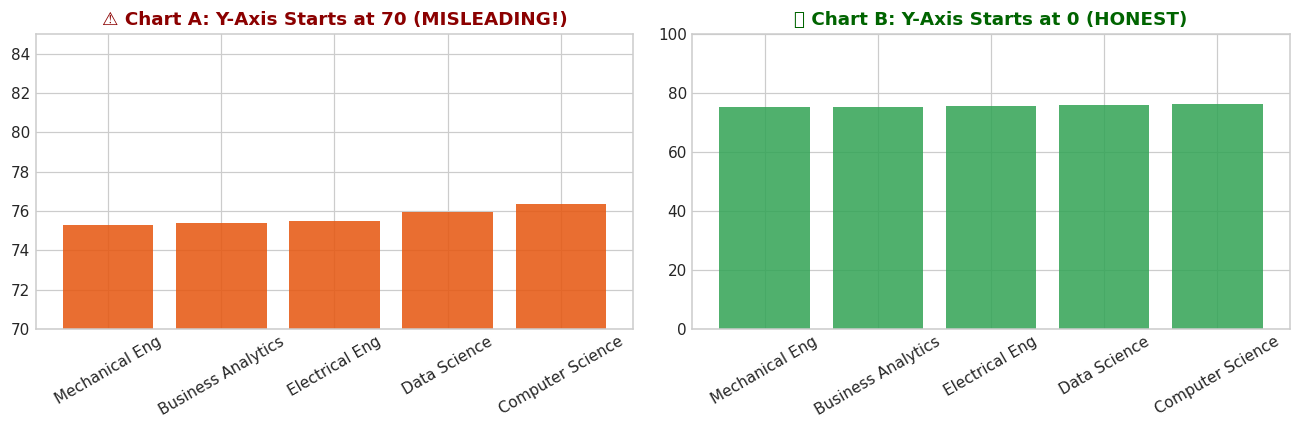

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Misleading: Truncated Y-axis (starts at 70)
axes[0].bar(major_stats.index, major_stats.values, color='#e6550d', alpha=0.85)
axes[0].set_title('⚠️ Chart A: Y-Axis Starts at 70 (MISLEADING!)', color='darkred', fontweight='bold')
axes[0].set_ylim(70, 85)
axes[0].tick_params(axis='x', rotation=30)

# Honest: Y-axis starts at 0
axes[1].bar(major_stats.index, major_stats.values, color='#31a354', alpha=0.85)
axes[1].set_title('✅ Chart B: Y-Axis Starts at 0 (HONEST)', color='darkgreen', fontweight='bold')
axes[1].set_ylim(0, 100)
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

**Questions for the Class:**
1. In **Chart A**, does it look like Computer Science scored *three times higher* than Mechanical Engineering?
2. In reality (Chart B), what is the actual difference between them? (74.2 vs 79.5 — less than 5 points!).

**Golden Rule of Data Ethics:**  
*Because the human brain interprets the height of a bar as its magnitude, bar charts MUST ALWAYS start at zero. Truncating the y-axis is the #1 trick used in misleading news infographics!*

---
## 4. Time Trend: Line Charts

**Purpose**: Track continuous changes, momentum, seasonal cycles, and trends over ordered time intervals.

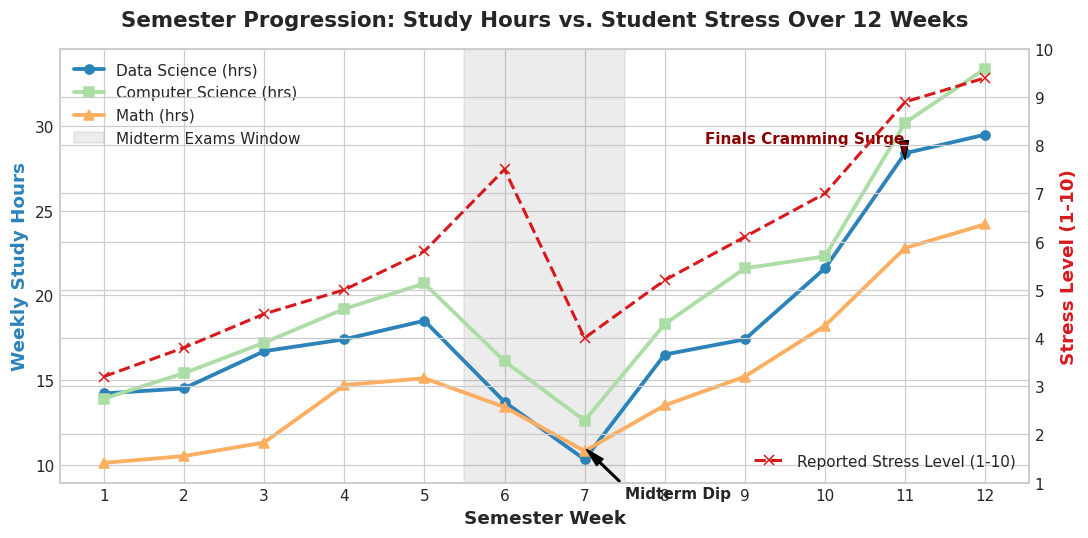

In [6]:
fig, ax1 = plt.subplots(figsize=(10, 5))

# Primary Y-axis: Study hours across 3 subjects
ax1.plot(df_weekly['week'], df_weekly['study_hours_datascience'], marker='o', linewidth=2.5, color='#2b83ba', label='Data Science (hrs)')
ax1.plot(df_weekly['week'], df_weekly['study_hours_cs'], marker='s', linewidth=2.5, color='#abdda4', label='Computer Science (hrs)')
ax1.plot(df_weekly['week'], df_weekly['study_hours_math'], marker='^', linewidth=2.5, color='#fdae61', label='Math (hrs)')
ax1.set_xlabel('Semester Week', fontsize=12, fontweight='bold')
ax1.set_ylabel('Weekly Study Hours', fontsize=12, fontweight='bold', color='#2b83ba')
ax1.set_xticks(df_weekly['week'])

# Secondary Y-axis: Stress Level (1 - 10)
ax2 = ax1.twinx()
ax2.plot(df_weekly['week'], df_weekly['stress_level'], color='#d7191c', linestyle='--', linewidth=2, marker='x', label='Reported Stress Level (1-10)')
ax2.set_ylabel('Stress Level (1-10)', fontsize=12, fontweight='bold', color='#d7191c')
ax2.set_ylim(1, 10)

# Add critical annotations
ax1.axvspan(5.5, 7.5, color='gray', alpha=0.15, label='Midterm Exams Window')
ax1.annotate('Midterm Dip', xy=(7, 11), xytext=(7.5, 8), 
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6), fontweight='bold')
ax1.annotate('Finals Cramming Surge', xy=(11, 28), xytext=(8.5, 29), 
             arrowprops=dict(facecolor='darkred', shrink=0.05, width=1, headwidth=6), fontweight='bold', color='darkred')

plt.title('Semester Progression: Study Hours vs. Student Stress Over 12 Weeks', fontsize=14, fontweight='bold', pad=15)
ax1.legend(loc='upper left')
ax2.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 💬 Analytic Discussion 3: Storytelling with Time Series

**Questions for the Class:**
1. What happened between **Week 6 and Week 7**? Why did study hours drop even though stress peaked? *(Insight: Midterm exams ended; students experienced burnout/relief right after).* 
2. What happens in **Weeks 11 and 12**? Look at the relationship between study hours and stress level. Is cramming sustainable?

---
## 5. Composition: Stacked Bar Chart vs. Pie Chart

**Purpose**: Show how individual parts make up a whole (100% or 24-hour day).

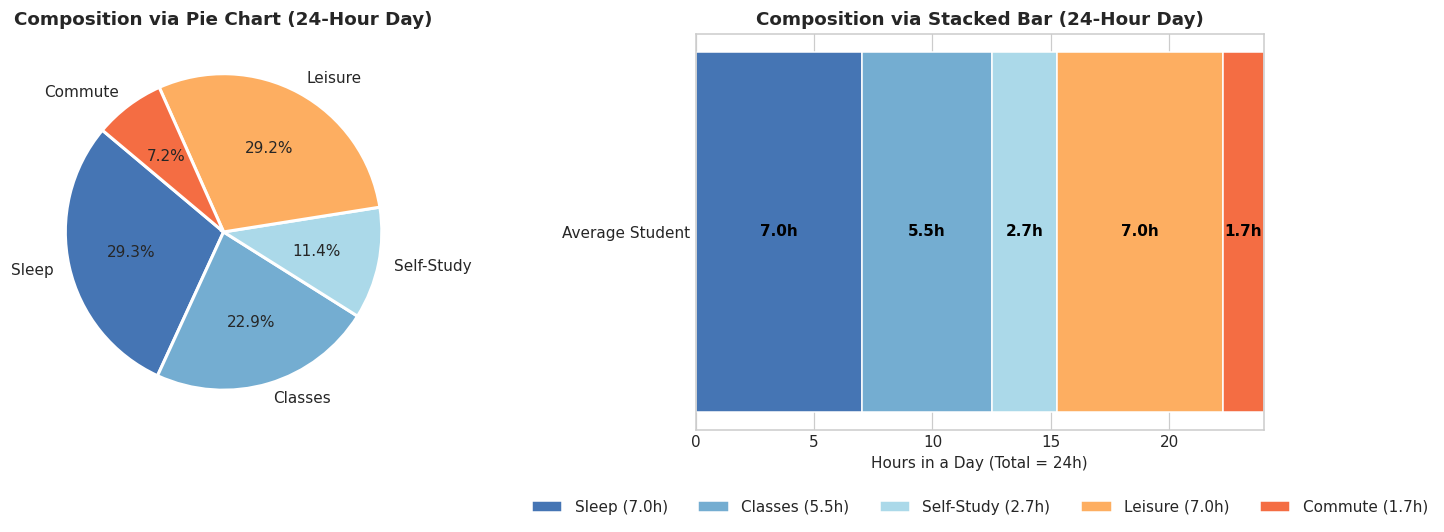

In [7]:
# Compute average daily 24-hour time budget across all students
time_budget = df[['daily_sleep_hrs', 'daily_classes_hrs', 'daily_study_hrs', 'daily_leisure_hrs', 'daily_commute_hrs']].mean()
labels = ['Sleep', 'Classes', 'Self-Study', 'Leisure', 'Commute']
colors = ['#4575b4', '#74add1', '#abd9e9', '#fdae61', '#f46d43']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Pie Chart (Common, but controversial!)
axes[0].pie(time_budget, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors, 
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Composition via Pie Chart (24-Hour Day)', fontweight='bold')

# 2. Stacked Horizontal Bar Chart (Recommended alternative!)
bottom = 0
for val, lab, col in zip(time_budget, labels, colors):
    axes[1].barh(['Average Student'], val, left=bottom, color=col, label=f"{lab} ({val:.1f}h)", edgecolor='white')
    # Add text label inside bar segment
    axes[1].text(bottom + val/2, 0, f"{val:.1f}h", ha='center', va='center', color='black', fontweight='bold')
    bottom += val

axes[1].set_title('Composition via Stacked Bar (24-Hour Day)', fontweight='bold')
axes[1].set_xlabel('Hours in a Day (Total = 24h)')
axes[1].set_xlim(0, 24)
axes[1].legend(loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=5)

plt.tight_layout()
plt.show()

### 💬 Analytic Discussion 4: Why Data Scientists Hate Pie Charts

**Look at the Pie Chart:**
1. Can you instantly tell whether **Classes (5.5h)** is larger or smaller than **Leisure (6.2h)** just by looking at the angle of the slices?
2. Now look at the **Stacked Bar**: Is it easier to compare lengths along a straight axis?

**The Science of Human Perception:**  
Psychophysics research shows human brains are exceptionally good at comparing **linear position and length**, but notoriously inaccurate at judging **2D angles and surface areas**.
- **Rule**: Limit pie charts to a maximum of 2 to 3 slices with stark differences (e.g. Yes 80% / No 20%). For 4+ categories, use a **bar chart** or **stacked bar**.

---
## 6. Relationship & Correlation: Scatter Plots & Heatmaps

**Purpose**: Analyze how two numerical features interact, detect correlations, and find clusters.

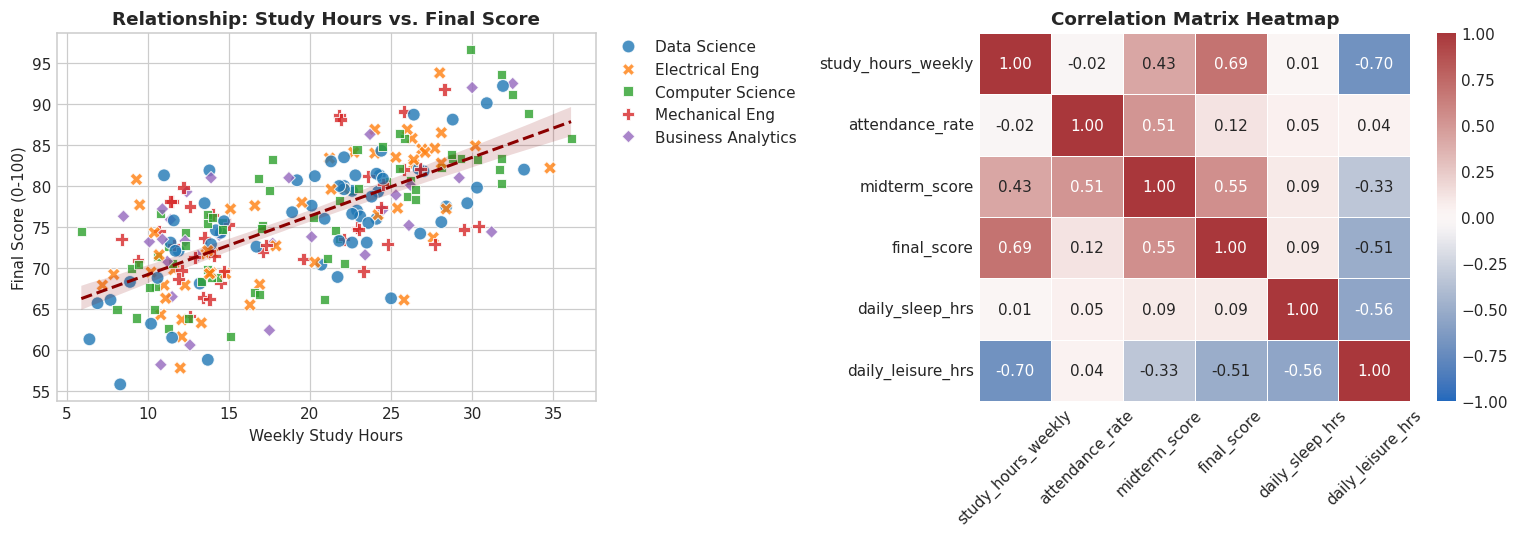

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Scatter Plot with Hue and Linear Trendline
sns.scatterplot(data=df, x='study_hours_weekly', y='final_score', hue='major', style='major', s=70, alpha=0.8, ax=axes[0])
sns.regplot(data=df, x='study_hours_weekly', y='final_score', scatter=False, ax=axes[0], color='darkred', line_kws=dict(linewidth=2, linestyle='--'))
axes[0].set_title('Relationship: Study Hours vs. Final Score', fontweight='bold')
axes[0].set_xlabel('Weekly Study Hours')
axes[0].set_ylabel('Final Score (0-100)')
axes[0].legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

# 2. Correlation Heatmap
corr_vars = ['study_hours_weekly', 'attendance_rate', 'midterm_score', 'final_score', 'daily_sleep_hrs', 'daily_leisure_hrs']
corr = df[corr_vars].corr()
sns.heatmap(corr, annot=True, cmap='vlag', vmin=-1, vmax=1, fmt='.2f', linewidths=0.5, ax=axes[1])
axes[1].set_title('Correlation Matrix Heatmap', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

---
## 7. Multiple Variables: Pair Plot

**Purpose**: When you have 4+ continuous features and want to inspect every pairwise scatter plot alongside each variable's distribution in a single command.

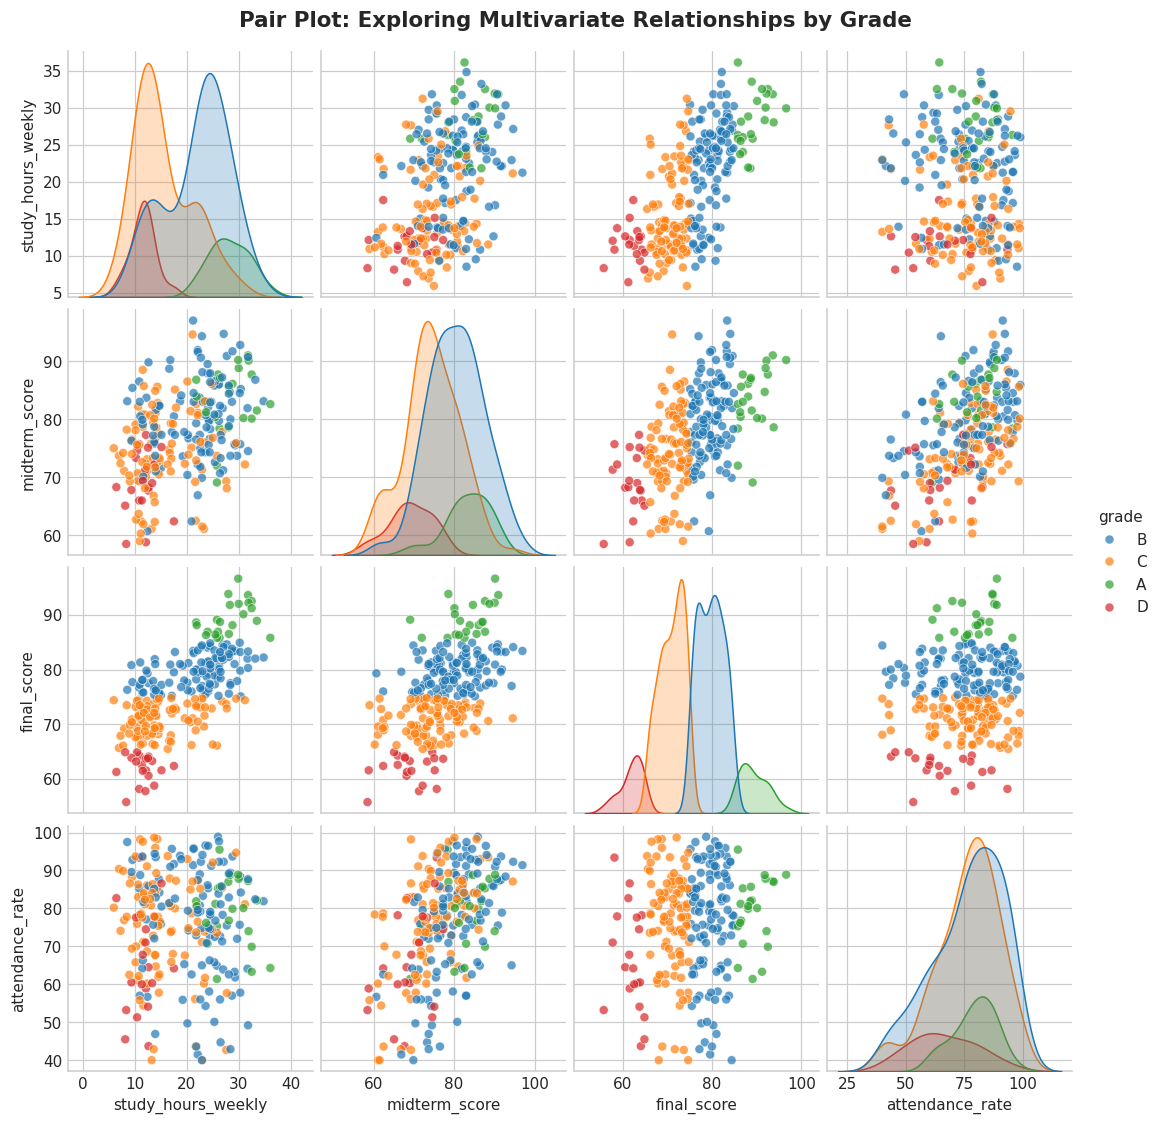

In [19]:
# Pair plot across 4 key continuous metrics, colored by grade category
pair_cols = ['study_hours_weekly', 'midterm_score', 'final_score', 'attendance_rate', 'grade']
g = sns.pairplot(df[pair_cols], hue='grade', palette='tab10', diag_kind='kde', plot_kws=dict(alpha=0.7, s=35))
g.fig.suptitle('Pair Plot: Exploring Multivariate Relationships by Grade', y=1.02, fontsize=14, fontweight='bold')
plt.show()

### 💬 Analytic Discussion 5: Reading the Multivariate Landscape

**Questions for the Class:**
1. Look down the **diagonal**: What do the diagonal plots show? *(They show the univariate distribution for each feature, split by Grade A, B, C, D, F)*.
2. Notice how Grade 'A' students (blue) and Grade 'F' students (brown/red) form **distinct separated clusters** in the `study_hours_weekly` vs `final_score` plot, but **overlap heavily** on `attendance_rate`.
3. What does this tell you about which feature is a stronger discriminator of performance?

---
## 8. Geographic Pattern: Regional Comparison (Mock Choropleth / Map)

**Purpose**: Explore spatial differences across regions or states.

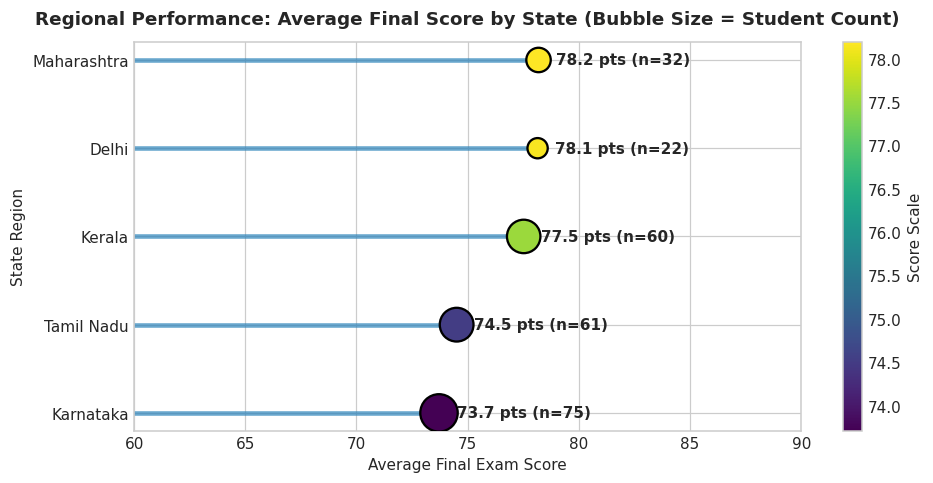

In [27]:
# Regional aggregation: Student count and average score by state
state_stats = df.groupby('state_region').agg(
    student_count=('student_id', 'count'),
    avg_score=('final_score', 'mean'),
    avg_study=('study_hours_weekly', 'mean')
).reset_index()

fig, ax = plt.subplots(figsize=(9, 4.5))

# Lollipop chart for clean geographic/state comparison
state_stats = state_stats.sort_values(by='avg_score')
ax.hlines(y=state_stats['state_region'], xmin=60, xmax=state_stats['avg_score'], color='#2b83ba', alpha=0.7, linewidth=3)
scatter = ax.scatter(state_stats['avg_score'], state_stats['state_region'], s=state_stats['student_count']*8, 
                     c=state_stats['avg_score'], cmap='viridis', edgecolors='black', linewidth=1.5, zorder=3)

# Add data labels
for idx, row in state_stats.iterrows():
    ax.text(row['avg_score'] + 0.8, row['state_region'], f"{row['avg_score']:.1f} pts (n={row['student_count']})", va='center', fontweight='semibold')

ax.set_xlim(60, 90)
ax.set_title('Regional Performance: Average Final Score by State (Bubble Size = Student Count)', fontweight='bold', pad=12)
ax.set_xlabel('Average Final Exam Score')
ax.set_ylabel('State Region')
plt.colorbar(scatter, label='Score Scale')
plt.tight_layout()
plt.show()

---
## 🎯 Summary: The Chart Selection Decision Matrix

Whenever you have a question about your data, use this cheat sheet to pick the exact chart:

| Analytical Question | Data Types Involved | Recommended Visualization |
|---|---|---|
| **Distribution** | 1 Continuous variable | **Histogram** (spread), **KDE** (shape), **Boxplot** (outliers) |
| **Comparison** | 1 Categorical + 1 Continuous | **Bar Chart** (`bar` or `barh`), Grouped Bar |
| **Relationship** | 2 Continuous variables | **Scatter Plot** (optionally with `hue` or `size`) |
| **Time Trend** | Date/Time + Continuous | **Line Chart** (with markers and shaded event bands) |
| **Composition** | Parts of a 100% total | **Stacked Bar Chart** (preferred) or 2-slice Pie Chart |
| **Correlation** | Many Continuous variables | **Correlation Heatmap** (`sns.heatmap`) |
| **Multiple Variables** | 3 to 6 Continuous variables | **Pair Plot** (`sns.pairplot`) |
| **Geographic** | Location + Metric | **Choropleth Map** or Ranked Lollipop Chart |